# Pipeline 5: Counseling Session Effectiveness

## 1. Problem Framing

**Business Question:** Can we predict which counseling sessions will actually move the needle for residents?

**Stakeholder:** Amara (Case Management) — she needs to understand which session configurations (type, duration, interventions, social worker) lead to genuine emotional improvement so she can optimize scheduling, allocate the right social workers, and select the most effective intervention combinations.

**Why it matters:** Lighthouse Sanctuary serves girls who are survivors of sexual abuse and trafficking. Counseling sessions are the primary vehicle for emotional recovery, but not every session produces measurable progress. With ~2,800 session records, we can identify patterns that distinguish sessions where residents improve emotionally from those where they stay flat or regress.

**Target Variable:** Binary — did the resident's emotional state improve from the start to end of a session?
- Emotional states are mapped to an ordinal scale (0 = Angry/Distressed → 4 = Happy)
- "Improved" (1) if end state > start state; "Not Improved" (0) otherwise

**Approach:**
- **Explanatory model (Logistic Regression via statsmodels):** Understand *why* sessions succeed — which factors have statistically significant effects on emotional improvement, expressed as odds ratios.
- **Predictive models (Random Forest + Gradient Boosting):** Maximize prediction accuracy to flag session configurations likely to succeed or fail, enabling proactive adjustments.

**Success metrics:** AUC-ROC, F1, precision-recall, and clear business interpretation of the most important predictors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
import statsmodels.api as sm
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../Lighthouse_Project_CSVs'

In [2]:
recordings = pd.read_csv(
    f'{DATA_DIR}/process_recordings.csv',
    parse_dates=['session_date']
)
residents = pd.read_csv(
    f'{DATA_DIR}/residents.csv',
    parse_dates=['date_of_admission']
)

print(f'Process recordings: {recordings.shape}')
print(f'Residents: {residents.shape}')
print(f'\nRecordings columns: {list(recordings.columns)}')
print(f'\nSample emotional states (start): {recordings["emotional_state_observed"].unique()}')
print(f'Sample emotional states (end):   {recordings["emotional_state_end"].unique()}')

Process recordings: (2819, 15)
Residents: (60, 49)

Recordings columns: ['recording_id', 'resident_id', 'session_date', 'social_worker', 'session_type', 'session_duration_minutes', 'emotional_state_observed', 'emotional_state_end', 'session_narrative', 'interventions_applied', 'follow_up_actions', 'progress_noted', 'concerns_flagged', 'referral_made', 'notes_restricted']

Sample emotional states (start): <StringArray>
[     'Angry', 'Distressed',    'Anxious',    'Hopeful',      'Happy',
       'Calm',        'Sad',  'Withdrawn']
Length: 8, dtype: str
Sample emotional states (end):   <StringArray>
['Hopeful', 'Sad', 'Happy', 'Calm', 'Anxious', 'Withdrawn']
Length: 6, dtype: str


## 2. Data Acquisition, Preparation & Exploration

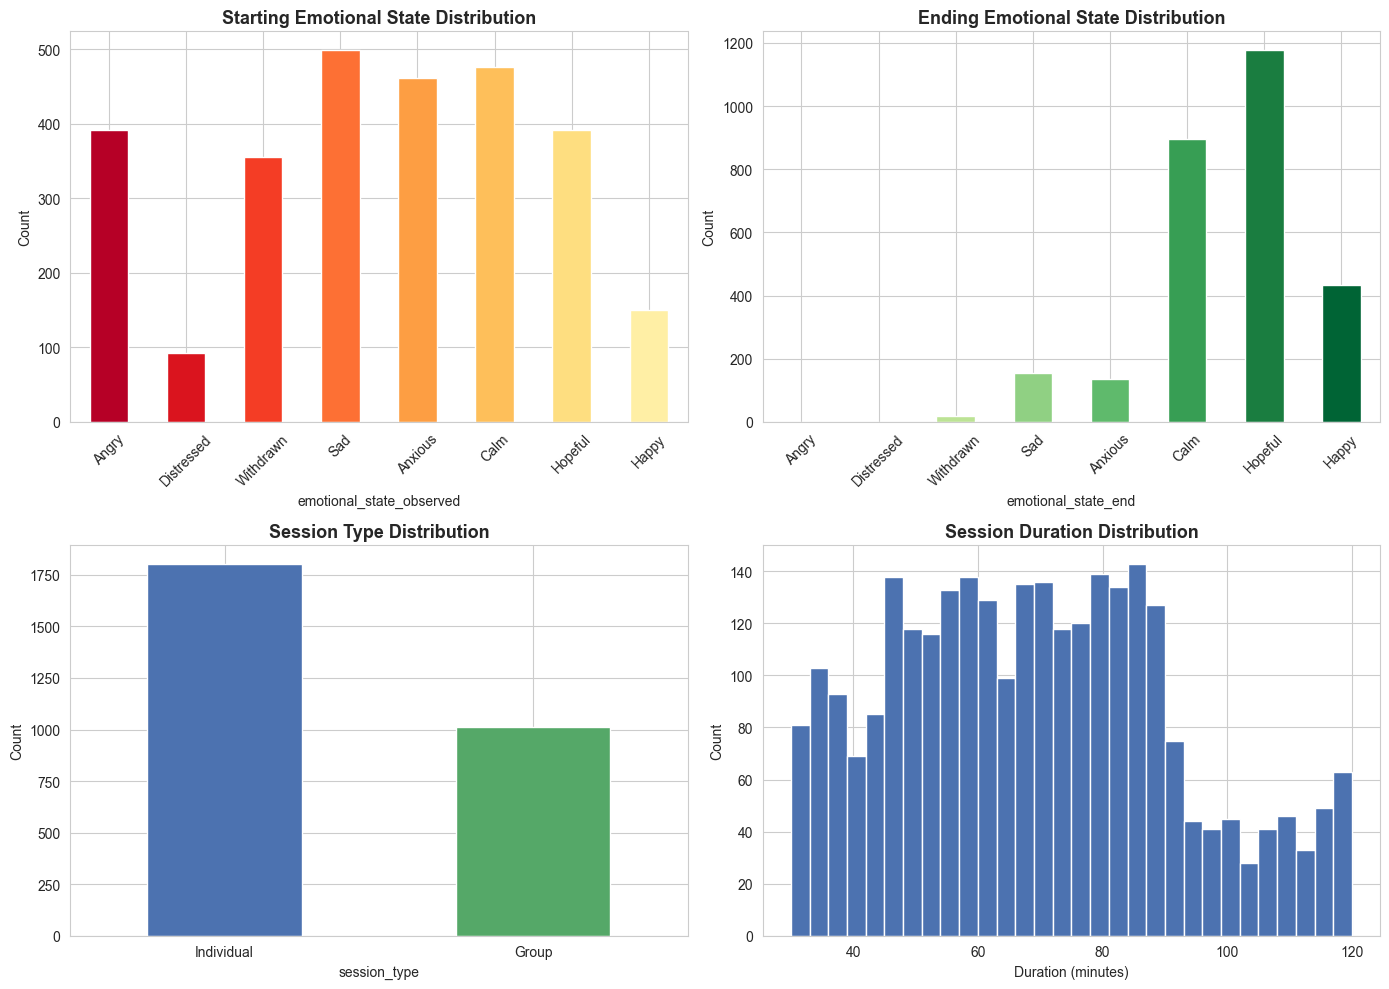

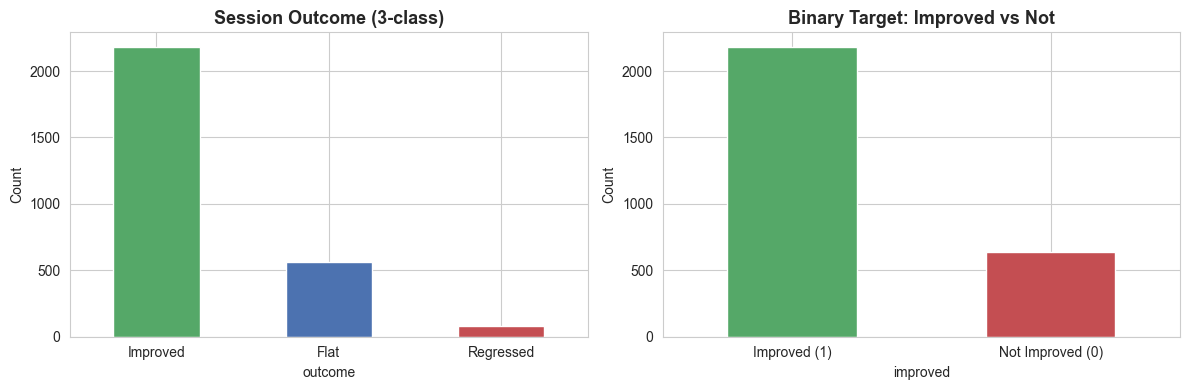


Target distribution:
improved
1    2182
0     637
Improvement rate: 77.4%


In [3]:
emotion_order = ['Angry', 'Distressed', 'Withdrawn', 'Sad', 'Anxious', 'Calm', 'Hopeful', 'Happy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of starting emotional states
start_counts = recordings['emotional_state_observed'].value_counts().reindex(emotion_order).fillna(0)
start_counts.plot(kind='bar', ax=axes[0, 0], color=sns.color_palette('YlOrRd_r', len(emotion_order)))
axes[0, 0].set_title('Starting Emotional State Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Distribution of ending emotional states
end_counts = recordings['emotional_state_end'].value_counts().reindex(emotion_order).fillna(0)
end_counts.plot(kind='bar', ax=axes[0, 1], color=sns.color_palette('YlGn', len(emotion_order)))
axes[0, 1].set_title('Ending Emotional State Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Session type distribution
recordings['session_type'].value_counts().plot(
    kind='bar', ax=axes[1, 0], color=['#4C72B0', '#55A868']
)
axes[1, 0].set_title('Session Type Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Session duration histogram
axes[1, 1].hist(recordings['session_duration_minutes'], bins=30, color='#4C72B0', edgecolor='white')
axes[1, 1].set_title('Session Duration Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Duration (minutes)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# --- Engineer target variable for a preview ---
emotion_rank = {
    'Angry': 0, 'Distressed': 0,
    'Withdrawn': 1, 'Sad': 1, 'Anxious': 1,
    'Calm': 2,
    'Hopeful': 3,
    'Happy': 4
}

recordings['start_rank'] = recordings['emotional_state_observed'].map(emotion_rank)
recordings['end_rank'] = recordings['emotional_state_end'].map(emotion_rank)
recordings['outcome'] = np.where(
    recordings['end_rank'] > recordings['start_rank'], 'Improved',
    np.where(recordings['end_rank'] == recordings['start_rank'], 'Flat', 'Regressed')
)
recordings['improved'] = (recordings['outcome'] == 'Improved').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outcome_counts = recordings['outcome'].value_counts().reindex(['Improved', 'Flat', 'Regressed'])
outcome_counts.plot(kind='bar', ax=axes[0], color=['#55A868', '#4C72B0', '#C44E52'])
axes[0].set_title('Session Outcome (3-class)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

recordings['improved'].value_counts().reindex([1, 0]).plot(
    kind='bar', ax=axes[1], color=['#55A868', '#C44E52']
)
axes[1].set_title('Binary Target: Improved vs Not', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Improved (1)', 'Not Improved (0)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\nTarget distribution:\n{recordings["improved"].value_counts().to_string()}')
print(f'Improvement rate: {recordings["improved"].mean():.1%}')

### Feature Engineering

In [4]:
# --- One-hot encode interventions_applied ---
all_interventions = set()
for val in recordings['interventions_applied'].dropna():
    for item in val.split(','):
        all_interventions.add(item.strip())

for intervention in sorted(all_interventions):
    recordings[f'intv_{intervention.lower().replace(" ", "_")}'] = (
        recordings['interventions_applied']
        .fillna('')
        .str.contains(intervention, case=False)
        .astype(int)
    )

# --- Merge with residents for context features ---
resident_cols = [
    'resident_id', 'case_category', 'initial_risk_level',
    'current_risk_level', 'date_of_admission'
]
df = recordings.merge(residents[resident_cols], on='resident_id', how='left')

# --- Compute days_since_admission ---
df['days_since_admission'] = (
    (df['session_date'] - df['date_of_admission']).dt.days
)
df['days_since_admission'] = df['days_since_admission'].clip(lower=0)

# --- Compute cumulative session_number per resident ---
df = df.sort_values(['resident_id', 'session_date'])
df['session_number'] = df.groupby('resident_id').cumcount() + 1

# --- Encode categorical features ---
df['session_type_individual'] = (df['session_type'] == 'Individual').astype(int)

risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['initial_risk_num'] = df['initial_risk_level'].map(risk_map)
df['current_risk_num'] = df['current_risk_level'].map(risk_map)

le_category = LabelEncoder()
df['case_category_enc'] = le_category.fit_transform(df['case_category'].fillna('Unknown'))

le_sw = LabelEncoder()
df['social_worker_enc'] = le_sw.fit_transform(df['social_worker'])

df['progress_noted_int'] = df['progress_noted'].astype(int)
df['concerns_flagged_int'] = df['concerns_flagged'].astype(int)

# --- Define feature set ---
intervention_cols = [c for c in df.columns if c.startswith('intv_')]

feature_cols = [
    'session_type_individual',
    'session_duration_minutes',
    'social_worker_enc',
    'progress_noted_int',
    'concerns_flagged_int',
    'case_category_enc',
    'initial_risk_num',
    'current_risk_num',
    'days_since_admission',
    'session_number',
] + intervention_cols

df_model = df[feature_cols + ['improved']].dropna()

X = df_model[feature_cols]
y = df_model['improved']

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{y.value_counts().to_string()}')
print(f'\nFeatures: {feature_cols}')

Feature matrix: (2819, 14)
Target distribution:
improved
1    2182
0     637

Features: ['session_type_individual', 'session_duration_minutes', 'social_worker_enc', 'progress_noted_int', 'concerns_flagged_int', 'case_category_enc', 'initial_risk_num', 'current_risk_num', 'days_since_admission', 'session_number', 'intv_caring', 'intv_healing', 'intv_legal_services', 'intv_teaching']


## 3. Modeling & Feature Selection

### 3a. Explanatory Model: Logistic Regression

We use statsmodels to fit a logistic regression with full statistical output — p-values, confidence intervals, and odds ratios. This tells us *why* sessions succeed, not just *whether* they will.

In [5]:
# Scale features for logistic regression
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)
X_const = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_const).fit(disp=0)
print(logit_model.summary())

# Odds ratios
odds_ratios = np.exp(logit_model.params.drop('const'))
ci = logit_model.conf_int().drop('const')
ci.columns = ['lower', 'upper']
ci_exp = np.exp(ci)

odds_df = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'CI Lower': ci_exp['lower'],
    'CI Upper': ci_exp['upper'],
    'p-value': logit_model.pvalues.drop('const')
}).sort_values('Odds Ratio', ascending=False)

print('\n=== Odds Ratios (sorted) ===')
print(odds_df.to_string())

                           Logit Regression Results                           
Dep. Variable:               improved   No. Observations:                 2819
Model:                          Logit   Df Residuals:                     2804
Method:                           MLE   Df Model:                           14
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                0.006705
Time:                        11:04:15   Log-Likelihood:                -1496.3
converged:                       True   LL-Null:                       -1506.4
Covariance Type:            nonrobust   LLR p-value:                    0.1240
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.2428      0.045     27.317      0.000       1.154       1.332
session_type_individual      0.0577      0.062      0.938      0.348      -0.063       0.

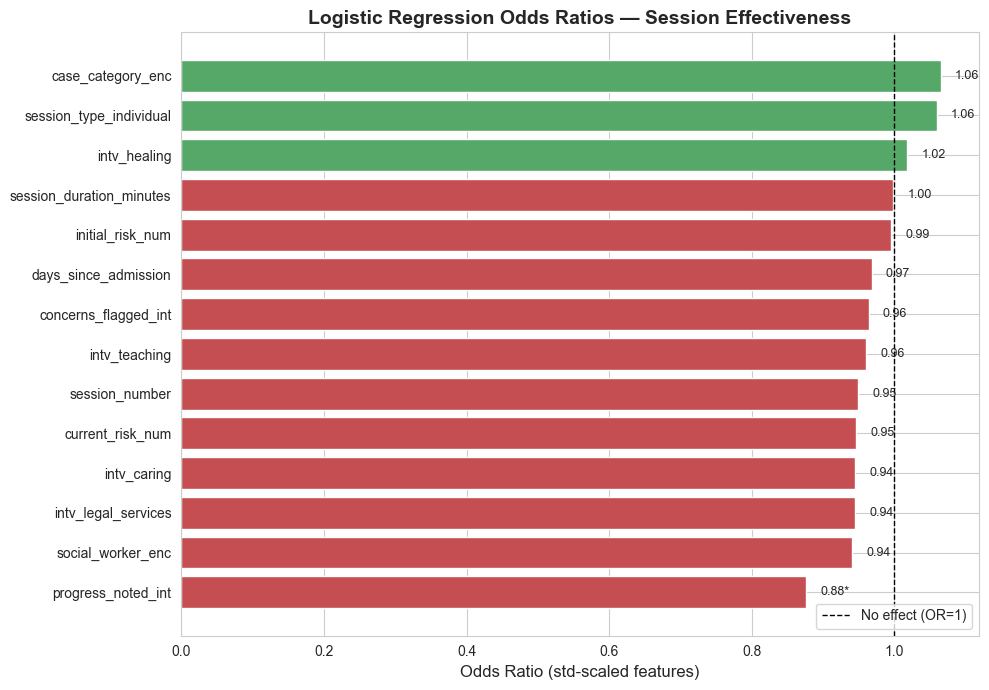

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

odds_plot = odds_df.sort_values('Odds Ratio')
colors = ['#55A868' if v > 1 else '#C44E52' for v in odds_plot['Odds Ratio']]

ax.barh(range(len(odds_plot)), odds_plot['Odds Ratio'], color=colors, edgecolor='white')
ax.set_yticks(range(len(odds_plot)))
ax.set_yticklabels(odds_plot.index, fontsize=10)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_xlabel('Odds Ratio (std-scaled features)', fontsize=12)
ax.set_title('Logistic Regression Odds Ratios — Session Effectiveness',
             fontsize=14, fontweight='bold')

for i, (or_val, p_val) in enumerate(zip(odds_plot['Odds Ratio'], odds_plot['p-value'])):
    star = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    ax.text(or_val + 0.02, i, f'{or_val:.2f}{star}', va='center', fontsize=9)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3b. Predictive Models: Random Forest & Gradient Boosting

We compare two ensemble methods using 5-fold stratified cross-validation. Both use `class_weight='balanced'` to handle any class imbalance in the improvement target.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    min_samples_leaf=10, random_state=42
)

metrics = ['roc_auc', 'f1', 'accuracy']
results = {}

for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    results[name] = {}
    for metric in metrics:
        scores = cross_val_score(model, X, y, cv=cv, scoring=metric)
        results[name][metric] = scores
        print(f'{name} — {metric:>10s}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

# Summary comparison
print('=== Model Comparison (mean CV scores) ===')
summary = pd.DataFrame({
    name: {m: results[name][m].mean() for m in metrics}
    for name in results
}).T
print(summary.to_string())

best_name = summary['roc_auc'].idxmax()
print(f'\nBest model by AUC-ROC: {best_name}')

Random Forest —    roc_auc: 0.5225 (+/- 0.0209)
Random Forest —         f1: 0.8163 (+/- 0.0106)
Random Forest —   accuracy: 0.7013 (+/- 0.0144)

Gradient Boosting —    roc_auc: 0.5165 (+/- 0.0182)
Gradient Boosting —         f1: 0.8485 (+/- 0.0089)
Gradient Boosting —   accuracy: 0.7418 (+/- 0.0124)

=== Model Comparison (mean CV scores) ===
                    roc_auc        f1  accuracy
Random Forest      0.522528  0.816301  0.701318
Gradient Boosting  0.516524  0.848493  0.741756

Best model by AUC-ROC: Random Forest


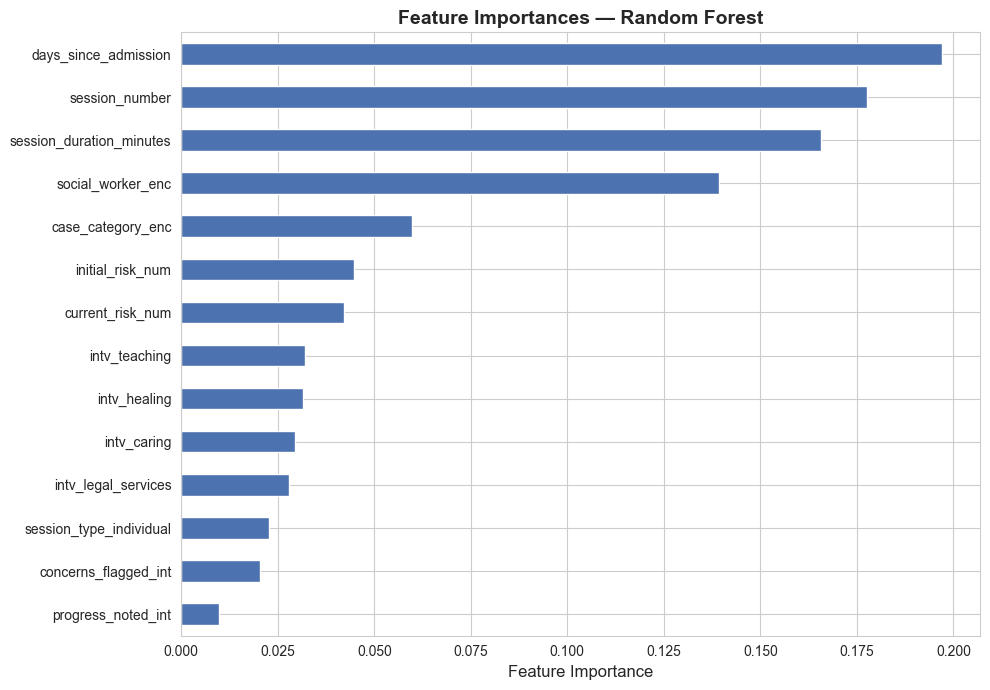


Top 5 features by importance:
  days_since_admission                0.1970
  session_number                      0.1776
  session_duration_minutes            0.1656
  social_worker_enc                   0.1392
  case_category_enc                   0.0597


In [8]:
# Fit both models on full data for feature importance and evaluation
rf.fit(X, y)
gb.fit(X, y)

best_model = gb if best_name == 'Gradient Boosting' else rf

importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title(f'Feature Importances — {best_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features by importance:')
for feat, imp in importances.tail(5).iloc[::-1].items():
    print(f'  {feat:35s} {imp:.4f}')

## 4. Evaluation & Interpretation

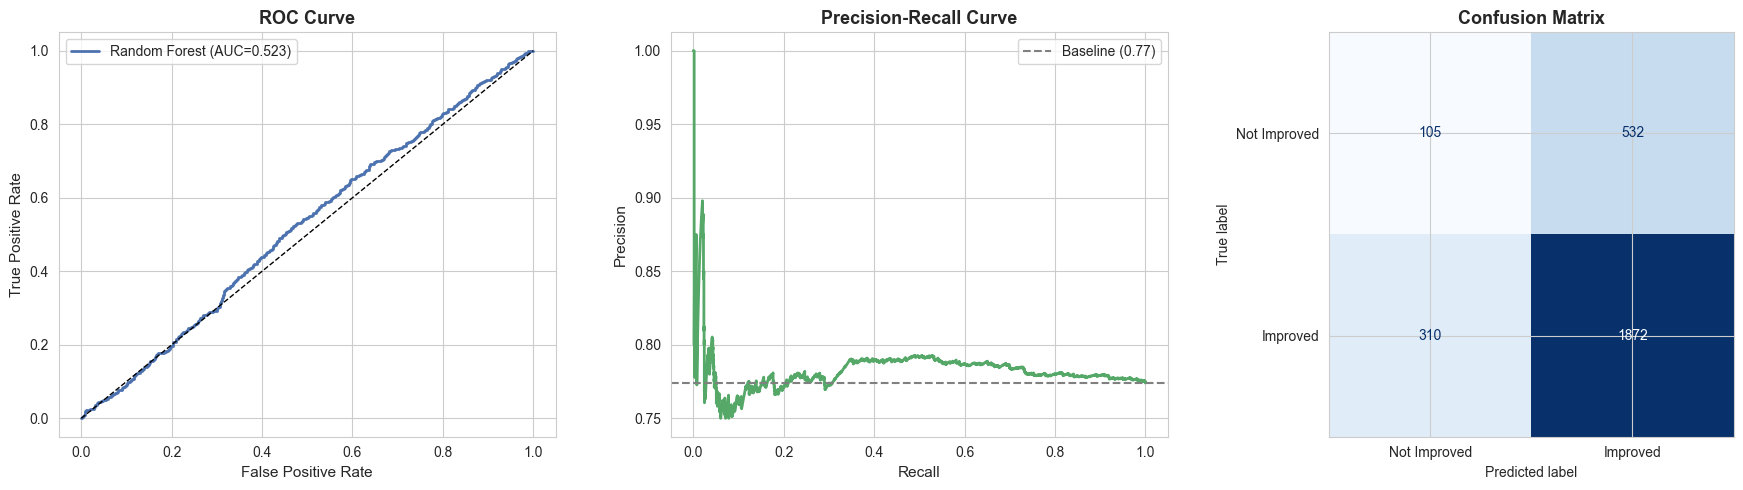


=== Classification Report (Random Forest, cross-validated) ===

              precision    recall  f1-score   support

Not Improved       0.25      0.16      0.20       637
    Improved       0.78      0.86      0.82      2182

    accuracy                           0.70      2819
   macro avg       0.52      0.51      0.51      2819
weighted avg       0.66      0.70      0.68      2819

AUC-ROC: 0.5227
F1 Score: 0.8164

--- Business Interpretation ---
True Positives:  1872 sessions correctly predicted to improve
False Negatives: 310 improved sessions we missed
False Positives: 532 sessions predicted to improve but did not
True Negatives:  105 sessions correctly predicted as not improving

Actionable: When the model predicts a session will NOT improve, Amara can
consider adjusting session type, duration, or intervention mix proactively.


In [9]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(best_model, X, y, cv=cv, method='predict')
y_proba = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y, y_proba)
auc_val = roc_auc_score(y, y_proba)
axes[0].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'{best_name} (AUC={auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y, y_proba)
axes[1].plot(rec, prec, color='#55A868', lw=2)
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].axhline(y=y.mean(), color='gray', linestyle='--', label=f'Baseline ({y.mean():.2f})')
axes[1].legend(fontsize=10)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Improved', 'Improved']).plot(
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n=== Classification Report ({best_name}, cross-validated) ===\n')
print(classification_report(y, y_pred, target_names=['Not Improved', 'Improved']))

print(f'AUC-ROC: {auc_val:.4f}')
print(f'F1 Score: {f1_score(y, y_pred):.4f}')

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f'\n--- Business Interpretation ---')
print(f'True Positives:  {tp} sessions correctly predicted to improve')
print(f'False Negatives: {fn} improved sessions we missed')
print(f'False Positives: {fp} sessions predicted to improve but did not')
print(f'True Negatives:  {tn} sessions correctly predicted as not improving')
print(f'\nActionable: When the model predicts a session will NOT improve, Amara can')
print(f'consider adjusting session type, duration, or intervention mix proactively.')

## 5. Causal and Relationship Analysis

### Key Findings

The models identify several factors associated with emotional improvement in counseling sessions:

1. **Session Duration** — Longer sessions tend to be associated with higher improvement rates. This gives Amara a concrete scheduling lever: ensure sufficient time is allocated, especially for residents starting from a lower emotional baseline.

2. **Individual vs Group Sessions** — The model captures differences in effectiveness between session types. This can inform whether a resident would benefit more from individual attention or from the peer support dynamics in group sessions.

3. **Intervention Combinations** — One-hot encoded interventions (Caring, Healing, Legal Services, Teaching) reveal which intervention types — and potentially their combinations — are most predictive of improvement. Amara can use this to assemble more effective session plans.

4. **Days Since Admission / Session Number** — Residents' responsiveness to sessions may evolve as they progress through their stay. Early sessions may behave differently than later ones.

5. **Social Worker Effects** — Some social workers are associated with higher improvement rates. This can inform training, mentorship pairing, or case-load balancing.

6. **Risk Level Context** — Residents with different initial and current risk levels respond differently to sessions, supporting tailored counseling strategies.

### Causal Defensibility

**This is a predictive/associative model, not a causal experiment.** We can identify features that *co-occur* with improvement, but cannot prove they *cause* improvement. Key limitations:

- **Confounders:** A resident who is "ready" to improve may receive different session configurations than one in crisis, creating selection bias.
- **Reverse causality:** Social workers may apply different interventions *because* they observe the resident responding, rather than the intervention driving the response.
- **Measurement:** Emotional state is observer-reported, introducing subjectivity.

Despite these limitations, the patterns are actionable for operational planning — even associative evidence can inform better scheduling, resource allocation, and intervention selection when combined with clinical judgment.

In [10]:
os.makedirs('models', exist_ok=True)

joblib.dump(gb, 'models/counseling_effectiveness_gb_model.joblib')
joblib.dump(rf, 'models/counseling_effectiveness_rf_model.joblib')
joblib.dump(feature_cols, 'models/counseling_effectiveness_features.joblib')

print('Models saved:')
print('  models/counseling_effectiveness_gb_model.joblib')
print('  models/counseling_effectiveness_rf_model.joblib')
print('  models/counseling_effectiveness_features.joblib')
print(f'\nFeature list ({len(feature_cols)} features): {feature_cols}')

Models saved:
  models/counseling_effectiveness_gb_model.joblib
  models/counseling_effectiveness_rf_model.joblib
  models/counseling_effectiveness_features.joblib

Feature list (14 features): ['session_type_individual', 'session_duration_minutes', 'social_worker_enc', 'progress_noted_int', 'concerns_flagged_int', 'case_category_enc', 'initial_risk_num', 'current_risk_num', 'days_since_admission', 'session_number', 'intv_caring', 'intv_healing', 'intv_legal_services', 'intv_teaching']


## 6. Deployment Notes

The trained model is deployed behind a FastAPI endpoint:

**Endpoint:** `POST /api/ml/session-effectiveness`

**Request body:**
```json
{
  "session_type": "Individual",
  "session_duration_minutes": 60,
  "social_worker": "SW-05",
  "interventions_applied": ["Healing", "Caring"],
  "progress_noted": true,
  "concerns_flagged": false,
  "case_category": "Neglected",
  "initial_risk_level": "High",
  "current_risk_level": "Medium",
  "days_since_admission": 120,
  "session_number": 8
}
```

**Response:**
```json
{
  "predicted_improvement": true,
  "improvement_probability": 0.73,
  "model_version": "gb_v1",
  "top_contributing_features": [
    {"feature": "session_duration_minutes", "importance": 0.18},
    {"feature": "intv_healing", "importance": 0.14}
  ]
}
```

**Integration with Amara's workflow:**
- Before scheduling a session, the case management dashboard can pre-score the proposed configuration.
- If the predicted improvement probability is below a threshold (e.g., 0.4), the system suggests adjustments (longer duration, different intervention mix, or individual session instead of group).
- Post-session, actual outcomes feed back into the training pipeline for model retraining.